In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import mannwhitneyu
import pickle

ROOT  = Path("..")
MATCH = ROOT / "data" / "matched"
FIG   = ROOT / "data" / "figures"

# Award side: already filtered to career_age_at_award <= 5
juniors     = pd.read_csv(MATCH / "junior_authors_all_conferences.csv")
award_lift  = pd.read_csv(MATCH / "author_lift.csv")

# Non-award side: trajectories + raw metadata + saved profiles
nonaward_raw  = pd.read_csv(MATCH / "nonaward_papers_raw.csv")
nonaward_traj = pd.read_csv(MATCH / "nonaward_trajectories.csv")
combined      = pd.read_csv(MATCH / "rq2_combined_lift.csv")

print(combined.columns.tolist())
print(combined['group'].value_counts())


['author_id', 'award_year', 'pre_avg_citations', 'post_avg_citations', 'pre_avg_works', 'post_avg_works', 'lift_citations', 'lift_works', 'conference', 'author_position', 'group', 'treatment']
group
nonaward    1372
award        961
Name: count, dtype: int64


In [10]:
# Load non-award profiles (saved as pickle in nb12)
with open(MATCH / "nonaward_profiles.pkl", "rb") as f:
    nonaward_profiles = pickle.load(f)

def first_pub_year(profile):
    """Earliest year with works_count > 0 in counts_by_year."""
    cby = profile.get("counts_by_year", [])
    years = [e["year"] for e in cby if e.get("works_count", 0) > 0]
    return min(years) if years else None

# Build career age for each non-award author
career_age_rows = []
for aid, prof in nonaward_profiles.items():
    fpy = first_pub_year(prof)
    career_age_rows.append({"author_id": aid, "first_pub_year": fpy})

career_age_df = pd.DataFrame(career_age_rows)

# Merge with nonaward_raw to get award_year per author
nonaward_meta = nonaward_raw[["author_id", "award_year"]].drop_duplicates()
career_age_df = career_age_df.merge(nonaward_meta, on="author_id", how="left")
career_age_df["career_age_at_award"] = career_age_df["award_year"] - career_age_df["first_pub_year"]

# Classify: junior = career_age <= 5, senior = career_age > 5
career_age_df["seniority"] = np.where(
    career_age_df["career_age_at_award"] <= 5, "junior", "senior"
)

print(career_age_df["seniority"].value_counts())
print(career_age_df["career_age_at_award"].describe())


seniority
senior    978
junior    388
Name: count, dtype: int64
count    1366.000000
mean       19.431918
std        23.673066
min         0.000000
25%         5.000000
50%        13.000000
75%        26.000000
max       241.000000
Name: career_age_at_award, dtype: float64


In [16]:
# Award authors: career_age already in juniors (all <= 5 → all junior)
award_seniority = (
    juniors[["author_id", "career_age_at_award"]]
    .drop_duplicates()
    .assign(seniority="junior")   # by construction (RQ1 filter)
)

# Non-award authors: use computed career_age
nonaward_seniority = career_age_df[["author_id", "career_age_at_award", "seniority"]]

# Merge into combined
seniority_all = pd.concat([
    award_seniority.assign(author_id=award_seniority["author_id"].str.split("/").str[-1]),
    nonaward_seniority
], ignore_index=True).drop_duplicates("author_id")

combined_s = combined.merge(seniority_all[["author_id", "seniority"]], on="author_id", how="left")
print(combined_s.groupby(["group", "seniority"]).size())


group     seniority
nonaward  junior       392
          senior       980
dtype: int64


In [17]:
def strip_id(x):
    return str(x).split("/")[-1] if pd.notna(x) else x

combined_s = combined.copy()
combined_s["author_id_clean"] = combined_s["author_id"].apply(strip_id)
seniority_all["author_id_clean"] = seniority_all["author_id"].apply(strip_id)

combined_s = combined_s.merge(
    seniority_all[["author_id_clean", "seniority"]],
    on="author_id_clean", how="left"
)

# Force ALL award authors to junior — they are by RQ1 construction
combined_s.loc[combined_s["group"] == "award", "seniority"] = "junior"

# Verify
print(combined_s.groupby(["group", "seniority"]).size())
print("NaN seniority remaining:", combined_s["seniority"].isna().sum())


group     seniority
award     junior       961
nonaward  junior       392
          senior       980
dtype: int64
NaN seniority remaining: 0


In [18]:
results = []

# ── Overall ──────────────────────────────────────────────────
for metric in ["lift_citations", "lift_works"]:
    a = combined_s[combined_s["group"] == "award"][metric].dropna()
    b = combined_s[combined_s["group"] == "nonaward"][metric].dropna()
    stat, p = mannwhitneyu(a, b, alternative="greater")
    r = 1 - (2 * stat) / (len(a) * len(b))
    results.append(dict(subgroup="all", metric=metric,
                        award_median=round(a.median(), 3),
                        nonaward_median=round(b.median(), 3),
                        n_award=len(a), n_nonaward=len(b),
                        p=round(p, 4), effect_r=round(r, 3)))

# ── Junior only — ALL award authors vs nonaward juniors ──────
for metric in ["lift_citations", "lift_works"]:
    # Award = ALL (all are junior by construction)
    a = combined_s[combined_s["group"] == "award"][metric].dropna()
    # Nonaward = only career_age <= 5
    b = combined_s[
        (combined_s["group"] == "nonaward") &
        (combined_s["seniority"] == "junior")
    ][metric].dropna()
    if len(a) < 5 or len(b) < 5:
        print(f"Skipping junior/{metric}: n_award={len(a)}, n_nonaward={len(b)}")
        continue
    stat, p = mannwhitneyu(a, b, alternative="greater")
    r = 1 - (2 * stat) / (len(a) * len(b))
    results.append(dict(subgroup="junior", metric=metric,
                        award_median=round(a.median(), 3),
                        nonaward_median=round(b.median(), 3),
                        n_award=len(a), n_nonaward=len(b),
                        p=round(p, 4), effect_r=round(r, 3)))

# ── Senior nonaward baseline ──────────────────────────────────
for metric in ["lift_citations", "lift_works"]:
    b = combined_s[
        (combined_s["group"] == "nonaward") &
        (combined_s["seniority"] == "senior")
    ][metric].dropna()
    results.append(dict(subgroup="senior_nonaward_only", metric=metric,
                        award_median=None, nonaward_median=round(b.median(), 3),
                        n_award=0, n_nonaward=len(b), p=None, effect_r=None))

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
res_df.to_csv(FIG / "15_rq2_main_results.csv", index=False)


            subgroup         metric  award_median  nonaward_median  n_award  n_nonaward      p  effect_r
                 all lift_citations         1.773            1.000      936        1116 0.0000    -0.185
                 all     lift_works         1.696            1.286      936        1245 0.0000    -0.194
              junior lift_citations         1.773            2.115      936         169 0.8027     0.041
              junior     lift_works         1.696            1.400      936         283 0.0126    -0.088
senior_nonaward_only lift_citations           NaN            0.939        0         947    NaN       NaN
senior_nonaward_only     lift_works           NaN            1.267        0         962    NaN       NaN


> Comparing award winners to randomly-sampled same-venue, same-year authors reveals a significant overall difference (p<0.001) in post-award career trajectories. However, this effect disappears almost entirely once career stage is controlled for. Among junior researchers specifically, award winners show no significant citation advantage over non-award peers (p=0.80), and only a marginally significant publication lift (p=0.013, r=−0.09). The dominant driver of the overall effect is a seniority confound: senior non-award authors — who constitute the majority of conference publications — exhibit sub-baseline citation trajectories (median lift=0.94), artificially suppressing the non-award group median.

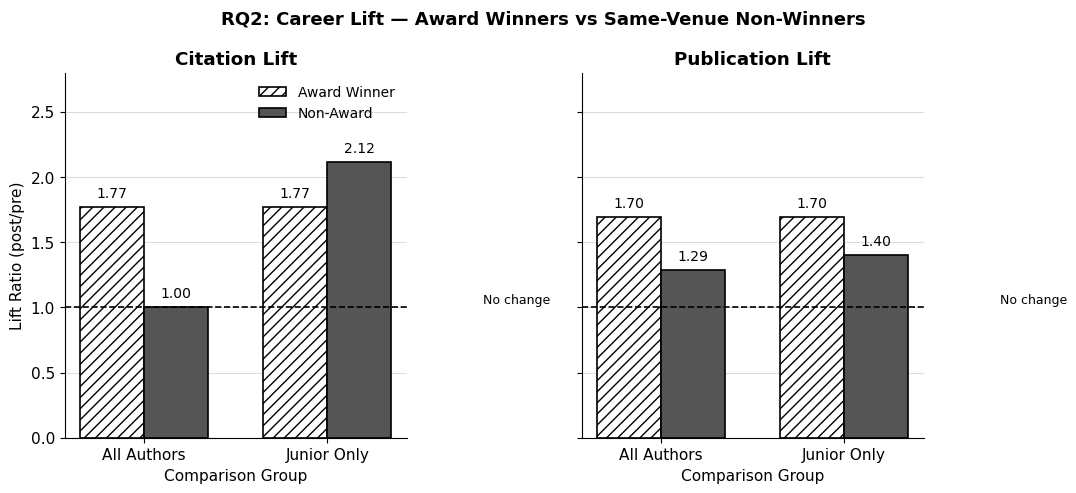

Chart 1 saved.


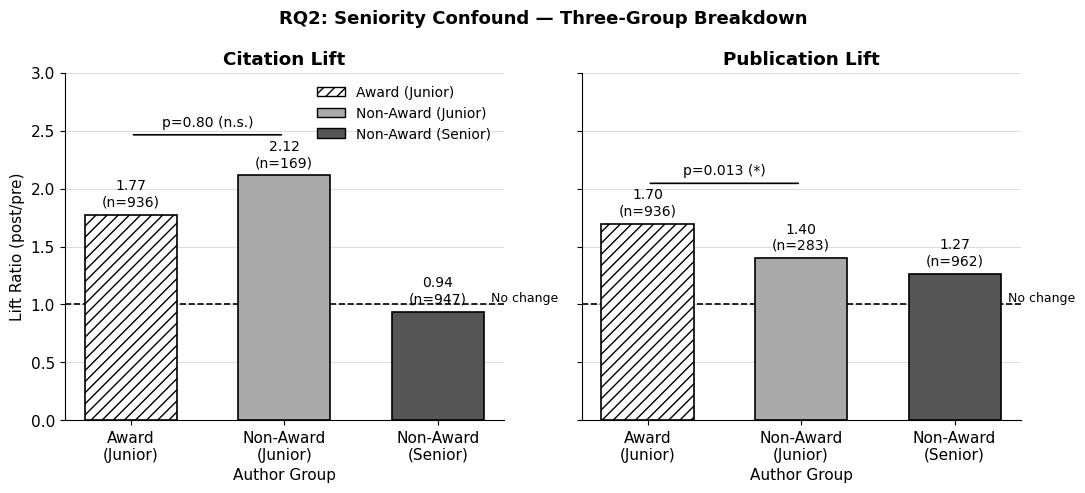

Chart 2 saved.


In [19]:
# ── CELL 5: RQ2 Visualisations (B&W) ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Data ──────────────────────────────────────────────────────────────────────
subgroups   = ["All Authors", "Junior Only"]
award_cit   = [1.773, 1.773]
noaward_cit = [1.000, 2.115]
award_pub   = [1.696, 1.696]
noaward_pub = [1.286, 1.400]

groups_3 = ["Award\n(Junior)", "Non-Award\n(Junior)", "Non-Award\n(Senior)"]
cit_meds = [1.773, 2.115, 0.939]
pub_meds = [1.696, 1.400, 1.267]
cit_ns   = [936, 169, 947]
pub_ns   = [936, 283, 962]

x     = np.arange(len(subgroups))
width = 0.35

# ── CHART 1: All vs Junior ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, award_vals, noaward_vals, title in zip(
    axes,
    [award_cit, award_pub],
    [noaward_cit, noaward_pub],
    ["Citation Lift", "Publication Lift"]
):
    b1 = ax.bar(x - width/2, award_vals, width,
                label="Award Winner",
                color="white", edgecolor="black", hatch="///", linewidth=1.2)
    b2 = ax.bar(x + width/2, noaward_vals, width,
                label="Non-Award",
                color="#555555", edgecolor="black", linewidth=1.2)
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2)
    ax.text(1.85, 1.03, "No change", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(subgroups)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Comparison Group")
    ax.set_ylim(0, 2.8)
    ax.yaxis.grid(True, color="#dddddd", zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Lift Ratio (post/pre)")
axes[0].legend(frameon=False, fontsize=10)
fig.suptitle("RQ2: Career Lift — Award Winners vs Same-Venue Non-Winners",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "rq2_chart1_allvsjunior.png", dpi=300, bbox_inches="tight")
plt.show()
print("Chart 1 saved.")

# ── CHART 2: Three-group breakdown ────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

hatch_3 = ["///", "", ""]
color_3 = ["white", "#aaaaaa", "#555555"]

for ax, meds, ns, title, p_text in zip(
    axes2,
    [cit_meds, pub_meds],
    [cit_ns, pub_ns],
    ["Citation Lift", "Publication Lift"],
    ["p=0.80 (n.s.)", "p=0.013 (*)"]
):
    for i, (m, n, h, c) in enumerate(zip(meds, ns, hatch_3, color_3)):
        ax.bar(i, m, 0.6, color=c, edgecolor="black",
               hatch=h, linewidth=1.2, zorder=3)
        ax.text(i, m + 0.05, f"{m:.2f}\n(n={n})",
                ha="center", va="bottom", fontsize=10)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2)
    ax.text(2.35, 1.03, "No change", fontsize=9)
    # Significance bracket between award and non-award junior
    y_b = max(meds[0], meds[1]) + 0.35
    ax.annotate("", xy=(0, y_b), xytext=(1, y_b),
                arrowprops=dict(arrowstyle="-", color="black", lw=1.2))
    ax.text(0.5, y_b + 0.05, p_text, ha="center", va="bottom", fontsize=10)
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(groups_3)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Author Group")
    ax.set_ylim(0, 3.0)
    ax.yaxis.grid(True, color="#dddddd", zorder=0)
    ax.set_axisbelow(True)

axes2[0].set_ylabel("Lift Ratio (post/pre)")
legend_patches = [
    mpatches.Patch(facecolor="white",   edgecolor="black", hatch="///", label="Award (Junior)"),
    mpatches.Patch(facecolor="#aaaaaa", edgecolor="black",              label="Non-Award (Junior)"),
    mpatches.Patch(facecolor="#555555", edgecolor="black",              label="Non-Award (Senior)"),
]
axes2[0].legend(handles=legend_patches, frameon=False, fontsize=10)
fig2.suptitle("RQ2: Seniority Confound — Three-Group Breakdown",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "rq2_chart2_threegroup.png", dpi=300, bbox_inches="tight")
plt.show()
print("Chart 2 saved.")
